In [15]:
from pathlib import Path
import json
import sys
import warnings
import gc

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

sns.set_context("talk")
sns.set_style("white")
warnings.filterwarnings("ignore", category=FutureWarning)

try:
    from IPython.display import display
except Exception:
    display = print


In [16]:
BASE = Path("/projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq")
SOURCE_NOTEBOOK = BASE / "Interpretability" / "knn_clustering_result" / "path10000.ipynb"
OUTPUT_DIR = SOURCE_NOTEBOOK.parent

EXPERT_MODEL_PATH = BASE / "ExPert" / "model" / "model.pt"
EXPERT_ADATA_PATH = BASE / "ExPert" / "anndata" / "merged.h5ad"
KEEPINGSCORE_RESULTS_DIR = BASE / "model_keeping_score" / "results_path10000"
MEAN_PATH = BASE / "datapoint_extraction" / "sample_mean" / "mean.npz"

CONTROL_NAME = "control"
TOP_K = 10
N_PERMUTATIONS = 10000
RANDOM_SEED = 20260509
FIG_DPI = 300
PREFIX = "path10000_control_correlation_attribution_enrichment"

print(f"[info] output dir = {OUTPUT_DIR}")
print(f"[info] top K      = {TOP_K}")


[info] output dir = /projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/Interpretability/knn_clustering_result
[info] top K      = 10


In [17]:
def load_pickled_npy(path):
    sys.modules.setdefault("numpy._core", np.core)
    sys.modules.setdefault("numpy._core.multiarray", np.core.multiarray)
    return np.load(path, allow_pickle=True)


def read_h5ad_var_names(h5ad_path):
    import h5py

    with h5py.File(h5ad_path, "r") as h5:
        var_index_key = h5["var"].attrs.get("_index", "_index")
        return h5["var"][var_index_key].asstr()[:].astype(str)


def build_linear_decoder_projection(model_path, h5ad_path, latent_dim):
    checkpoint = torch.load(model_path, map_location="cpu")
    state_dict = checkpoint["model_state_dict"]
    first_key = "decoder.px_decoder.fc_layers.weight"
    second_key = "decoder.px_scale_decoder.0.weight"
    for key in (first_key, second_key):
        if key not in state_dict:
            decoder_keys = [k for k in state_dict if "decoder" in k and k.endswith("weight")]
            raise KeyError(f"Missing {key}. Available decoder weights include: {decoder_keys[:25]}")

    w_first = state_dict[first_key].detach().cpu().float().numpy()
    w_second = state_dict[second_key].detach().cpu().float().numpy()
    if w_first.shape[1] < latent_dim:
        raise ValueError(f"{first_key} has {w_first.shape[1]} columns but latent_dim is {latent_dim}")
    if w_second.shape[1] != w_first.shape[0]:
        raise ValueError(f"Decoder matrix mismatch: {w_second.shape} cannot follow {w_first.shape}")

    # ExPert decoder input starts with z; remaining columns are covariates/class embeddings.
    W_dec = w_second @ w_first[:, :latent_dim]
    gene_names = read_h5ad_var_names(h5ad_path)
    if W_dec.shape[0] != len(gene_names):
        n_keep = min(W_dec.shape[0], len(gene_names))
        print(f"[warn] decoder genes {W_dec.shape[0]} != adata genes {len(gene_names)}; truncating to {n_keep}")
        W_dec = W_dec[:n_keep]
        gene_names = gene_names[:n_keep]
    return W_dec.astype(np.float32), gene_names, [first_key, second_key]


def convert_ll_comp_to_final_components(ll_comp, ll_final):
    if ll_comp.ndim == 3:
        if ll_comp.shape[:2] != ll_final.shape:
            raise ValueError(f"ll_comp first two dims {ll_comp.shape[:2]} do not match ll_final {ll_final.shape}")
        return ll_comp, "ll_comp interpreted as [G, P, D]"
    if ll_comp.ndim == 4:
        if ll_comp.shape[:2] != ll_final.shape:
            raise ValueError(f"ll_comp first two dims {ll_comp.shape[:2]} do not match ll_final {ll_final.shape}")
        cand_last = ll_comp[:, :, -1, :]
        cand_sum = ll_comp.sum(axis=2)
        err_last = np.mean(np.abs(cand_last.sum(axis=-1) - ll_final))
        err_sum = np.mean(np.abs(cand_sum.sum(axis=-1) - ll_final))
        if err_last <= err_sum:
            return cand_last, f"ll_comp interpreted as [G, P, T, D], using final time slice (MAE={err_last:.3e})"
        return cand_sum, f"ll_comp interpreted as [G, P, T, D], summing over time (MAE={err_sum:.3e})"
    raise ValueError(f"Unsupported ll_comp shape: {ll_comp.shape}")


def perturbation_to_gene(name, gene_to_idx):
    if name in gene_to_idx:
        return name
    for sep in ("+", "_", "-"):
        candidate = str(name).split(sep)[0]
        if candidate in gene_to_idx:
            return candidate
    return None


def load_sample_mean(mean_path, control_name=CONTROL_NAME):
    mean_data = np.load(mean_path, allow_pickle=True)
    required = {"X_mean", "y", "names"}
    missing = required.difference(mean_data.files)
    if missing:
        raise KeyError(f"{mean_path} is missing required arrays: {sorted(missing)}")

    X_mean = np.asarray(mean_data["X_mean"], dtype=np.float32)
    mean_labels = np.asarray(mean_data["y"]).astype(int)
    perturbation_names = np.asarray(mean_data["names"]).astype(str)

    if X_mean.shape[0] != len(mean_labels) or X_mean.shape[0] != len(perturbation_names):
        raise ValueError(
            f"mean.npz row mismatch: X_mean={X_mean.shape}, y={mean_labels.shape}, names={perturbation_names.shape}"
        )
    if len(np.unique(mean_labels)) != len(mean_labels):
        raise ValueError("mean.npz labels are not unique; cannot align rows unambiguously")
    if len(np.unique(perturbation_names)) != len(perturbation_names):
        raise ValueError("mean.npz names are not unique; cannot align perturbations unambiguously")

    name_to_label = {name: i for i, name in enumerate(perturbation_names)}
    if control_name not in name_to_label:
        raise ValueError(f"Expected {control_name!r} in mean.npz names")
    control_label = name_to_label[control_name]
    if int(mean_labels[control_label]) != int(control_label):
        raise ValueError(
            "This analysis expects mean.npz y labels to index names directly; "
            f"control is at names index {control_label} but y={mean_labels[control_label]}"
        )

    return X_mean, mean_labels, perturbation_names, control_label


def align_component_rows(ll_comp_final, mean_labels, perturbation_names):
    if ll_comp_final.shape[0] != len(mean_labels):
        raise ValueError(
            f"ll_comp has {ll_comp_final.shape[0]} rows, but mean.npz has {len(mean_labels)} labels"
        )
    if np.any((mean_labels < 0) | (mean_labels >= len(perturbation_names))):
        raise ValueError("mean.npz labels fall outside perturbation names bounds")
    if np.array_equal(mean_labels, np.arange(len(mean_labels))):
        return ll_comp_final

    aligned = np.zeros((len(perturbation_names), *ll_comp_final.shape[1:]), dtype=ll_comp_final.dtype)
    aligned[mean_labels] = ll_comp_final
    return aligned


def build_attribution_matrix_by_decoding(mapping_df, W_dec, control_label, mean_labels, perturbation_names):
    print("[info] directly decoding KeepingSCORE latent profiles from ll_comp.npy / ll_final.npy")
    ll_final = np.load(KEEPINGSCORE_RESULTS_DIR / "ll_final.npy")
    ll_comp = load_pickled_npy(KEEPINGSCORE_RESULTS_DIR / "ll_comp.npy")
    ll_comp_final, comp_msg = convert_ll_comp_to_final_components(ll_comp, ll_final)
    print(f"[info] {comp_msg}")

    ll_comp_final = align_component_rows(ll_comp_final, mean_labels, perturbation_names)
    latent_profiles = ll_comp_final.mean(axis=1).astype(np.float32)
    control_profile = latent_profiles[control_label]

    row_labels = mapping_df["label"].to_numpy(dtype=int)
    row_perts = mapping_df["perturbation"].to_numpy(dtype=str)
    column_mask = mapping_df["is_mapped_to_decoder_gene"].to_numpy(dtype=bool)
    column_gene_idx = mapping_df.loc[column_mask, "gene_index"].to_numpy(dtype=int)

    # Control-referenced KeepingSCORE latent profile for each perturbation row,
    # decoded in this script with the same linear decoder projection used above.
    keeping_score_latent_delta = latent_profiles[row_labels] - control_profile[None, :]
    decoded_target_delta = keeping_score_latent_delta @ W_dec[column_gene_idx, :].T

    pert_vs_pert = np.full((len(row_perts), len(row_perts)), np.nan, dtype=np.float32)
    pert_vs_pert[:, column_mask] = decoded_target_delta
    del ll_comp, ll_comp_final, latent_profiles, keeping_score_latent_delta, decoded_target_delta
    gc.collect()
    return pd.DataFrame(pert_vs_pert, index=row_perts, columns=row_perts)


In [18]:
X_mean, mean_labels, perturbation_names, control_label = load_sample_mean(MEAN_PATH)
latent_dim = X_mean.shape[1]
print(f"[info] perturbation labels = {len(perturbation_names)}")
print(f"[info] control label       = {control_label}")
print(f"[info] X_mean shape        = {X_mean.shape}")
print(f"[info] mean_path           = {MEAN_PATH}")


[info] perturbation labels = 98
[info] control label       = 97
[info] X_mean shape        = (98, 384)
[info] mean_path           = /projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/datapoint_extraction/sample_mean/mean.npz


In [19]:
W_dec, gene_names, decoder_layers = build_linear_decoder_projection(EXPERT_MODEL_PATH, EXPERT_ADATA_PATH, latent_dim)
gene_to_idx = {gene: i for i, gene in enumerate(gene_names)}
print("[info] decoder layers used:")
for layer in decoder_layers:
    print(f"  - {layer}")
print(f"[info] W_dec shape = {W_dec.shape} [genes, latent_dim]")


[info] decoder layers used:
  - decoder.px_decoder.fc_layers.weight
  - decoder.px_scale_decoder.0.weight
[info] W_dec shape = (13992, 384) [genes, latent_dim]


In [20]:
mapping_rows = []
for label, pert in enumerate(perturbation_names):
    if pert == CONTROL_NAME:
        continue
    gene = perturbation_to_gene(pert, gene_to_idx)
    mapping_rows.append({
        "label": int(label),
        "mean_label": int(mean_labels[label]),
        "perturbation": pert,
        "gene": gene,
        "gene_index": np.nan if gene is None else int(gene_to_idx[gene]),
        "is_mapped_to_decoder_gene": gene is not None,
    })

mapping_df = pd.DataFrame(mapping_rows)
mapped_df = mapping_df.loc[mapping_df["is_mapped_to_decoder_gene"]].copy()
if mapped_df.empty:
    raise ValueError("No perturbation names could be mapped to decoder genes.")

mapping_out = OUTPUT_DIR / f"{PREFIX}_perturbation_gene_mapping.csv"
mapping_df.to_csv(mapping_out, index=False)
print(f"[saved] {mapping_out}")
print(f"[info] retained non-control perturbations = {len(mapping_df)}")
print(f"[info] mapped perturbation genes          = {len(mapped_df)}")
display(mapping_df.head(20))


[saved] /projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/Interpretability/knn_clustering_result/path10000_control_correlation_attribution_enrichment_perturbation_gene_mapping.csv
[info] retained non-control perturbations = 97
[info] mapped perturbation genes          = 51


,label,mean_label,perturbation,gene,gene_index,is_mapped_to_decoder_gene
0,0,0,EIF1,EIF1,1374.0,True
1,1,1,PSMB5,PSMB5,3602.0,True
2,2,2,ANKRD11,ANKRD11,241.0,True
3,3,3,PTMA,PTMA,3643.0,True
4,4,4,NFRKB,None,NaN,False
5,5,5,HSP90B1,HSP90B1,2089.0,True
6,6,6,TFAM,TFAM,4647.0,True
7,7,7,CSNK2B,None,NaN,False
8,8,8,C17orf58,C17orf58,571.0,True
9,9,9,MED19,None,NaN,False


In [21]:
mapped_perts = mapped_df["perturbation"].to_numpy(dtype=str)
mapped_gene_idx = mapped_df["gene_index"].to_numpy(dtype=int)
mapped_gene_names = mapped_df["gene"].to_numpy(dtype=str)

X_mean_delta = X_mean - X_mean[control_label][None, :]
non_control_mean_mask = perturbation_names != CONTROL_NAME
decoded_mean_mapped = (X_mean_delta[non_control_mean_mask] @ W_dec[mapped_gene_idx, :].T).astype(np.float32, copy=False)
mean_corr = np.corrcoef(decoded_mean_mapped, rowvar=False)
mean_corr = np.nan_to_num(mean_corr, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
mean_corr_df = pd.DataFrame(mean_corr, index=mapped_perts, columns=mapped_perts)

corr_out = OUTPUT_DIR / f"{PREFIX}_decoded_sample_mean_gene_correlations.csv"
mean_corr_df.to_csv(corr_out)
print(f"[saved] {corr_out}")
print(f"[info] decoded_mean_mapped shape = {decoded_mean_mapped.shape}")
display(mean_corr_df.iloc[:8, :8])


[saved] /projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/Interpretability/knn_clustering_result/path10000_control_correlation_attribution_enrichment_decoded_sample_mean_gene_correlations.csv
[info] decoded_mean_mapped shape = (97, 51)


,EIF1,PSMB5,ANKRD11,PTMA,HSP90B1,TFAM,C17orf58,ACTB
EIF1,1.000000,0.715830,0.424404,0.714485,0.721544,0.370735,0.114994,-0.213818
PSMB5,0.715830,1.000000,0.053842,0.882227,0.726530,0.436706,0.277327,-0.389858
ANKRD11,0.424404,0.053842,1.000000,0.156419,0.307906,0.000065,-0.207130,0.147175
PTMA,0.714485,0.882227,0.156419,1.000000,0.774031,0.453828,0.226732,-0.360641
HSP90B1,0.721544,0.726530,0.307906,0.774031,1.000000,0.171127,0.007007,-0.475837
TFAM,0.370735,0.436706,0.000065,0.453828,0.171127,1.000000,0.596352,0.349219
C17orf58,0.114994,0.277327,-0.207130,0.226732,0.007007,0.596352,1.000000,0.180628
ACTB,-0.213818,-0.389858,0.147175,-0.360641,-0.475837,0.349219,0.180628,1.000000


In [22]:
pert_vs_pert_df = build_attribution_matrix_by_decoding(mapping_df, W_dec, control_label, mean_labels, perturbation_names)
pert_vs_pert_df = pert_vs_pert_df.loc[mapped_perts, mapped_perts].astype(float)
if not np.isfinite(pert_vs_pert_df.to_numpy()).all():
    raise ValueError("Mapped perturbation-vs-perturbation attribution matrix contains non-finite values.")

attr_out = OUTPUT_DIR / f"{PREFIX}_mapped_attribution_matrix_used.csv"
pert_vs_pert_df.to_csv(attr_out)
print(f"[saved] {attr_out}")
print(f"[info] mapped attribution matrix = {pert_vs_pert_df.shape}")
display(pert_vs_pert_df.iloc[:8, :8])


[info] directly decoding KeepingSCORE latent profiles from ll_comp.npy / ll_final.npy
[info] ll_comp interpreted as [G, P, D]
[saved] /projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/Interpretability/knn_clustering_result/path10000_control_correlation_attribution_enrichment_mapped_attribution_matrix_used.csv
[info] mapped attribution matrix = (51, 51)


,EIF1,PSMB5,ANKRD11,PTMA,HSP90B1,TFAM,C17orf58,ACTB
EIF1,0.048811,0.321387,0.286055,0.294027,0.300942,0.494699,0.214341,0.510573
PSMB5,0.046309,0.267361,0.227116,0.249439,0.272827,0.408971,0.129681,0.413152
ANKRD11,0.857152,1.089432,0.920220,1.413718,1.194170,0.858266,0.434553,1.651229
PTMA,-0.775025,-0.466059,-0.290692,-0.695357,-0.540574,-0.108829,-0.042930,-0.772277
HSP90B1,0.267608,0.498803,0.426268,0.591920,0.476738,0.489406,0.235144,0.745908
TFAM,0.223016,0.439516,0.425786,0.537084,0.545762,0.522661,0.231147,0.693104
C17orf58,-0.313202,-0.016667,-0.024358,-0.137658,-0.101653,0.172851,0.087906,-0.006782
ACTB,0.125505,0.456104,0.464499,0.485527,0.453716,0.576681,0.256959,0.676842


In [23]:
rows = []
attr = pert_vs_pert_df.to_numpy(dtype=float)
corr = mean_corr_df.loc[mapped_perts, mapped_perts].to_numpy(dtype=float)
n = len(mapped_perts)

for i, row_pert in enumerate(mapped_perts):
    order = np.argsort(np.abs(attr[i]))[::-1]
    rank_by_abs = np.empty(n, dtype=int)
    rank_by_abs[order] = np.arange(1, n + 1)
    for j, target_pert in enumerate(mapped_perts):
        if i == j:
            continue
        rows.append({
            "row_perturbation": row_pert,
            "row_gene": mapped_gene_names[i],
            "target_perturbation_gene": target_pert,
            "target_gene": mapped_gene_names[j],
            "decoder_delta_vs_control": attr[i, j],
            "abs_decoder_delta_vs_control": abs(attr[i, j]),
            "rank_abs_decoder_delta_within_row": int(rank_by_abs[j]),
            "is_top_k_abs_attribution": bool(rank_by_abs[j] <= TOP_K),
            "decoded_sample_mean_corr": corr[i, j],
            "abs_decoded_sample_mean_corr": abs(corr[i, j]),
        })

pair_df = pd.DataFrame(rows)
pair_out = OUTPUT_DIR / f"{PREFIX}_pair_level_topK{TOP_K}.csv"
pair_df.to_csv(pair_out, index=False)
print(f"[saved] {pair_out}")
print(f"[info] pair rows = {len(pair_df)}")
display(pair_df.head(20))


[saved] /projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/Interpretability/knn_clustering_result/path10000_control_correlation_attribution_enrichment_pair_level_topK10.csv
[info] pair rows = 2550


,row_perturbation,row_gene,target_perturbation_gene,target_gene,decoder_delta_vs_control,abs_decoder_delta_vs_control,rank_abs_decoder_delta_within_row,is_top_k_abs_attribution,decoded_sample_mean_corr,abs_decoded_sample_mean_corr
0,EIF1,EIF1,PSMB5,PSMB5,0.321387,0.321387,16,False,0.715830,0.715830
1,EIF1,EIF1,ANKRD11,ANKRD11,0.286055,0.286055,22,False,0.424404,0.424404
2,EIF1,EIF1,PTMA,PTMA,0.294027,0.294027,19,False,0.714485,0.714485
3,EIF1,EIF1,HSP90B1,HSP90B1,0.300942,0.300942,18,False,0.721544,0.721544
4,EIF1,EIF1,TFAM,TFAM,0.494699,0.494699,4,True,0.370735,0.370735
5,EIF1,EIF1,C17orf58,C17orf58,0.214341,0.214341,27,False,0.114994,0.114994
6,EIF1,EIF1,ACTB,ACTB,0.510573,0.510573,2,True,-0.213818,0.213818
7,EIF1,EIF1,YEATS2,YEATS2,0.024803,0.024803,50,False,-0.335966,0.335966
8,EIF1,EIF1,RPL41,RPL41,0.374385,0.374385,12,False,0.773282,0.773282
9,EIF1,EIF1,SIN3A,SIN3A,0.186016,0.186016,33,False,-0.454527,0.454527


In [24]:
top_df = pair_df.loc[pair_df["is_top_k_abs_attribution"]].copy()
background_df = pair_df.loc[~pair_df["is_top_k_abs_attribution"]].copy()
mw_abs = mannwhitneyu(top_df["abs_decoded_sample_mean_corr"], background_df["abs_decoded_sample_mean_corr"], alternative="greater")
mw_signed = mannwhitneyu(top_df["decoded_sample_mean_corr"], background_df["decoded_sample_mean_corr"], alternative="greater")

observed_mean_abs_top = float(top_df["abs_decoded_sample_mean_corr"].mean())
observed_mean_abs_background = float(background_df["abs_decoded_sample_mean_corr"].mean())
observed_mean_signed_top = float(top_df["decoded_sample_mean_corr"].mean())
observed_mean_signed_background = float(background_df["decoded_sample_mean_corr"].mean())

print("[observed pooled]")
print(f"  mean |r| top        = {observed_mean_abs_top:.6g}")
print(f"  mean |r| background = {observed_mean_abs_background:.6g}")
print(f"  Mann-Whitney |r| one-sided p = {mw_abs.pvalue:.6g}")
print(f"  mean r top          = {observed_mean_signed_top:.6g}")
print(f"  mean r background   = {observed_mean_signed_background:.6g}")
print(f"  Mann-Whitney r one-sided p   = {mw_signed.pvalue:.6g}")


[observed pooled]
  mean |r| top        = 0.469534
  mean |r| background = 0.454371
  Mann-Whitney |r| one-sided p = 0.107443
  mean r top          = 0.267127
  mean r background   = 0.264452
  Mann-Whitney r one-sided p   = 0.364361


In [25]:
rng = np.random.default_rng(RANDOM_SEED)
row_observed = []
null_mean_abs = np.zeros(N_PERMUTATIONS, dtype=float)
null_mean_signed = np.zeros(N_PERMUTATIONS, dtype=float)
row_count_for_null = 0

for row_pert, sub in pair_df.groupby("row_perturbation", sort=False):
    top_mask = sub["is_top_k_abs_attribution"].to_numpy(dtype=bool)
    k = int(top_mask.sum())
    if k == 0:
        continue
    abs_values = sub["abs_decoded_sample_mean_corr"].to_numpy(dtype=float)
    signed_values = sub["decoded_sample_mean_corr"].to_numpy(dtype=float)
    row_observed.append({
        "row_perturbation": row_pert,
        "n_top": k,
        "mean_abs_corr_top": float(abs_values[top_mask].mean()),
        "mean_signed_corr_top": float(signed_values[top_mask].mean()),
    })

    # Vectorized row-wise null: for this perturbation row, sample k target genes
    # without replacement per permutation.
    random_scores = rng.random((N_PERMUTATIONS, len(abs_values)))
    sampled = np.argpartition(random_scores, kth=k - 1, axis=1)[:, :k]
    null_mean_abs += abs_values[sampled].mean(axis=1)
    null_mean_signed += signed_values[sampled].mean(axis=1)
    row_count_for_null += 1

row_observed_df = pd.DataFrame(row_observed)
observed_row_weighted_mean_abs = float(row_observed_df["mean_abs_corr_top"].mean())
observed_row_weighted_mean_signed = float(row_observed_df["mean_signed_corr_top"].mean())

if row_count_for_null == 0:
    raise ValueError("No rows had top-K targets for the row-wise null.")
null_mean_abs /= row_count_for_null
null_mean_signed /= row_count_for_null

perm_p_abs = (1.0 + float(np.sum(null_mean_abs >= observed_row_weighted_mean_abs))) / (N_PERMUTATIONS + 1.0)
perm_p_signed = (1.0 + float(np.sum(null_mean_signed >= observed_row_weighted_mean_signed))) / (N_PERMUTATIONS + 1.0)

row_obs_out = OUTPUT_DIR / f"{PREFIX}_rowwise_observed_topK{TOP_K}.csv"
null_out = OUTPUT_DIR / f"{PREFIX}_rowwise_permutation_null_topK{TOP_K}.csv"
row_observed_df.to_csv(row_obs_out, index=False)
pd.DataFrame({"perm_mean_abs_corr": null_mean_abs, "perm_mean_signed_corr": null_mean_signed}).to_csv(null_out, index=False)
print(f"[saved] {row_obs_out}")
print(f"[saved] {null_out}")
print("[row-wise permutation]")
print(f"  observed row-mean |r| = {observed_row_weighted_mean_abs:.6g}")
print(f"  null mean |r|         = {np.mean(null_mean_abs):.6g}")
print(f"  empirical p |r|       = {perm_p_abs:.6g}")
print(f"  observed row-mean r   = {observed_row_weighted_mean_signed:.6g}")
print(f"  null mean r           = {np.mean(null_mean_signed):.6g}")
print(f"  empirical p r         = {perm_p_signed:.6g}")


[saved] /projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/Interpretability/knn_clustering_result/path10000_control_correlation_attribution_enrichment_rowwise_observed_topK10.csv
[saved] /projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/Interpretability/knn_clustering_result/path10000_control_correlation_attribution_enrichment_rowwise_permutation_null_topK10.csv
[row-wise permutation]
  observed row-mean |r| = 0.46972
  null mean |r|         = 0.457514
  empirical p |r|       = 0.0946905
  observed row-mean r   = 0.268306
  null mean r           = 0.265103
  empirical p r         = 0.423758


In [26]:
summary = {
    "source_notebook": str(SOURCE_NOTEBOOK),
    "attribution_matrix_source": "direct_decode_from_KeepingSCORE_ll_comp_and_linear_decoder_projection",
    "output_dir": str(OUTPUT_DIR),
    "top_k": int(TOP_K),
    "n_permutations": int(N_PERMUTATIONS),
    "random_seed": int(RANDOM_SEED),
    "mean_path": str(MEAN_PATH),
    "correlation_matrix_source": "decoded_sample_mean_delta_profiles_from_mean_npz",
    "n_sample_mean_profiles_for_correlation": int(decoded_mean_mapped.shape[0]),
    "latent_dim": int(latent_dim),
    "n_mapped_perturbation_genes": int(len(mapped_perts)),
    "n_pair_rows_excluding_self": int(len(pair_df)),
    "pooled_mean_abs_corr_top": observed_mean_abs_top,
    "pooled_mean_abs_corr_background": observed_mean_abs_background,
    "pooled_delta_mean_abs_corr_top_minus_background": observed_mean_abs_top - observed_mean_abs_background,
    "pooled_mannwhitney_abs_corr_greater_p": float(mw_abs.pvalue),
    "pooled_mean_signed_corr_top": observed_mean_signed_top,
    "pooled_mean_signed_corr_background": observed_mean_signed_background,
    "pooled_delta_mean_signed_corr_top_minus_background": observed_mean_signed_top - observed_mean_signed_background,
    "pooled_mannwhitney_signed_corr_greater_p": float(mw_signed.pvalue),
    "rowwise_observed_mean_abs_corr_top": observed_row_weighted_mean_abs,
    "rowwise_null_mean_abs_corr": float(np.mean(null_mean_abs)),
    "rowwise_null_sd_abs_corr": float(np.std(null_mean_abs, ddof=1)),
    "rowwise_empirical_abs_corr_greater_p": float(perm_p_abs),
    "rowwise_observed_mean_signed_corr_top": observed_row_weighted_mean_signed,
    "rowwise_null_mean_signed_corr": float(np.mean(null_mean_signed)),
    "rowwise_null_sd_signed_corr": float(np.std(null_mean_signed, ddof=1)),
    "rowwise_empirical_signed_corr_greater_p": float(perm_p_signed),
    "primary_interpretation": "Use abs_decoded_sample_mean_corr if high correlation means strong co-variation regardless of sign; use decoded_sample_mean_corr if only positive co-expression is intended.",
}

summary_json = OUTPUT_DIR / f"{PREFIX}_summary_topK{TOP_K}.json"
summary_csv = OUTPUT_DIR / f"{PREFIX}_summary_topK{TOP_K}.csv"
with open(summary_json, "w") as f:
    json.dump(summary, f, indent=2)
pd.DataFrame([summary]).to_csv(summary_csv, index=False)
print(f"[saved] {summary_json}")
print(f"[saved] {summary_csv}")
display(pd.DataFrame([summary]).T)


[saved] /projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/Interpretability/knn_clustering_result/path10000_control_correlation_attribution_enrichment_summary_topK10.json
[saved] /projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/Interpretability/knn_clustering_result/path10000_control_correlation_attribution_enrichment_summary_topK10.csv


,0
source_notebook,/projects/b1042/GoyalLab/jaekj/KeepingScore/pe...
attribution_matrix_source,direct_decode_from_KeepingSCORE_ll_comp_and_li...
output_dir,/projects/b1042/GoyalLab/jaekj/KeepingScore/pe...
top_k,10
n_permutations,10000
random_seed,20260509
mean_path,/projects/b1042/GoyalLab/jaekj/KeepingScore/pe...
correlation_matrix_source,decoded_sample_mean_delta_profiles_from_mean_npz
n_sample_mean_profiles_for_correlation,97
latent_dim,384


[saved] /projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/Interpretability/knn_clustering_result/path10000_control_correlation_attribution_enrichment_topK10_abs_corr_enrichment.png
[saved] /projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/Interpretability/knn_clustering_result/path10000_control_correlation_attribution_enrichment_topK10_abs_corr_enrichment.svg


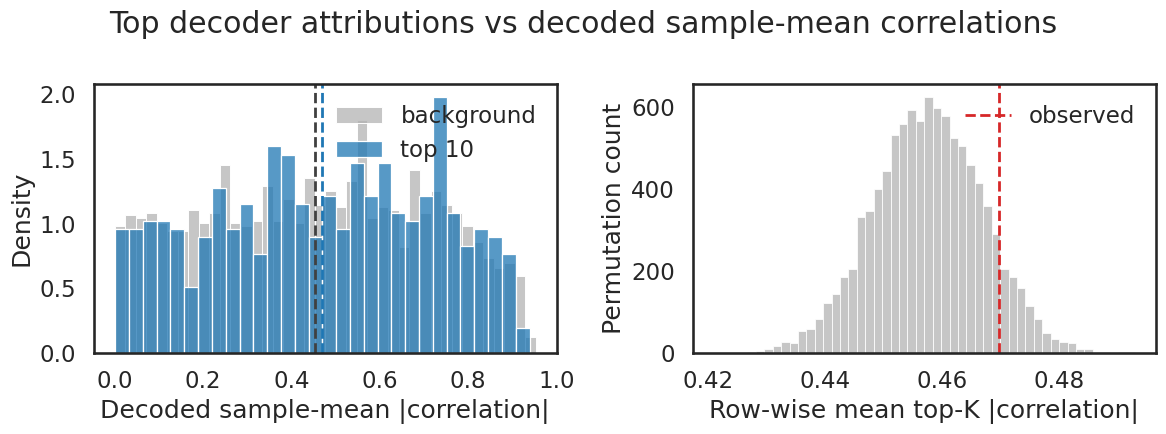

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(background_df["abs_decoded_sample_mean_corr"], bins=40, stat="density", color="0.7", label="background", ax=axes[0])
sns.histplot(top_df["abs_decoded_sample_mean_corr"], bins=30, stat="density", color="#1f77b4", label=f"top {TOP_K}", ax=axes[0])
axes[0].axvline(observed_mean_abs_top, color="#1f77b4", linestyle="--", linewidth=2)
axes[0].axvline(observed_mean_abs_background, color="0.25", linestyle="--", linewidth=2)
axes[0].set_xlabel("Decoded sample-mean |correlation|")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False)

sns.histplot(null_mean_abs, bins=50, color="0.7", ax=axes[1])
axes[1].axvline(observed_row_weighted_mean_abs, color="#d62728", linestyle="--", linewidth=2, label="observed")
axes[1].set_xlabel("Row-wise mean top-K |correlation|")
axes[1].set_ylabel("Permutation count")
axes[1].legend(frameon=False)
fig.suptitle("Top decoder attributions vs decoded sample-mean correlations")
fig.tight_layout()

plot_png = OUTPUT_DIR / f"{PREFIX}_topK{TOP_K}_abs_corr_enrichment.png"
plot_svg = OUTPUT_DIR / f"{PREFIX}_topK{TOP_K}_abs_corr_enrichment.svg"
fig.savefig(plot_png, dpi=FIG_DPI, bbox_inches="tight")
fig.savefig(plot_svg, dpi=FIG_DPI, bbox_inches="tight")
print(f"[saved] {plot_png}")
print(f"[saved] {plot_svg}")
plt.show()


[saved] /projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/Interpretability/knn_clustering_result/path10000_control_correlation_attribution_enrichment_topK10_pair_boxplot.png
[saved] /projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/Interpretability/knn_clustering_result/path10000_control_correlation_attribution_enrichment_topK10_pair_boxplot.svg


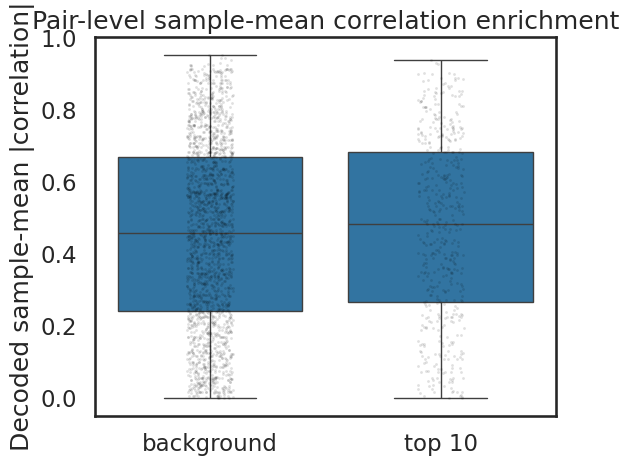

In [28]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_sample = pair_df.copy()
plot_sample["top_status"] = np.where(plot_sample["is_top_k_abs_attribution"], f"top {TOP_K}", "background")
sns.boxplot(data=plot_sample, x="top_status", y="abs_decoded_sample_mean_corr", order=["background", f"top {TOP_K}"], ax=ax, fliersize=1.5)
sns.stripplot(data=plot_sample, x="top_status", y="abs_decoded_sample_mean_corr", order=["background", f"top {TOP_K}"], ax=ax, color="black", alpha=0.12, size=2)
ax.set_xlabel("")
ax.set_ylabel("Decoded sample-mean |correlation|")
ax.set_title("Pair-level sample-mean correlation enrichment")
fig.tight_layout()

box_png = OUTPUT_DIR / f"{PREFIX}_topK{TOP_K}_pair_boxplot.png"
box_svg = OUTPUT_DIR / f"{PREFIX}_topK{TOP_K}_pair_boxplot.svg"
fig.savefig(box_png, dpi=FIG_DPI, bbox_inches="tight")
fig.savefig(box_svg, dpi=FIG_DPI, bbox_inches="tight")
print(f"[saved] {box_png}")
print(f"[saved] {box_svg}")
plt.show()
